In [9]:
plt.rcParams['figure.dpi'] = 230

In [1]:
p2fld = pl.Path('/Volumes/stu3data2/bnf_radsys_data/bnfradsys43m60sS10.c1/0.2/bnfradsys43m60sS10.c1.20260514.nc')

In [4]:
ds = xr.open_dataset(p2fld)

In [13]:
ds.mask_clear_sky_shortwave_radflux

<xarray.DataArray 'mask_clear_sky_shortwave_radflux' (time: 1440)> Size: 1kB
[1440 values with dtype=bool]
Coordinates:
  * time     (time) datetime64[ns] 12kB 2026-05-14T00:00:30 ... 2026-05-14T23...
Attributes:
    info:           Radflux clear sky mask according to Long & Ackerman (2000...
    unit:           1
    long_name:      clear sky classification mask
    flag_values:    0, 1
    flag_meanings:  0: fails radflux clear-sky test (cloudy), 1: passes radfl...

In [14]:
ds.mask_diffuse_magnitude

<xarray.DataArray 'mask_diffuse_magnitude' (time: 1440)> Size: 1kB
array([ True,  True,  True, ...,  True,  True,  True], shape=(1440,))
Coordinates:
  * time     (time) datetime64[ns] 12kB 2026-05-14T00:00:30 ... 2026-05-14T23...
Attributes:
    info:           Mask based on diffuse shortwave magnitude test. See Long ...
    unit:           1
    long_name:      clear sky classification mask
    flag_values:    0, 1
    flag_meanings:  0: fails diffuse magnitude test (cloudy), 1: passes diffu...

In [15]:
ds.mask_global_irradiance_variability

<xarray.DataArray 'mask_global_irradiance_variability' (time: 1440)> Size: 1kB
array([ True,  True,  True, ...,  True,  True,  True], shape=(1440,))
Coordinates:
  * time     (time) datetime64[ns] 12kB 2026-05-14T00:00:30 ... 2026-05-14T23...
Attributes:
    info:           Mask based on change-with-time test on global shortwave (...
    unit:           1
    long_name:      clear sky classification mask
    flag_values:    0, 1
    flag_meanings:  0: fails change-with-time test (cloudy), 1: passes change...

In [16]:
ds.mask_normalized_diffuse_ratio_variability

<xarray.DataArray 'mask_normalized_diffuse_ratio_variability' (time: 1440)> Size: 1kB
array([False, False, False, ..., False, False, False], shape=(1440,))
Coordinates:
  * time     (time) datetime64[ns] 12kB 2026-05-14T00:00:30 ... 2026-05-14T23...
Attributes:
    info:           Mask based on normalized diffuse ratio (NDR) variability ...
    unit:           1
    long_name:      clear sky classification mask
    flag_values:    0, 1
    flag_meanings:  0: fails NDR variability test (cloudy), 1: passes NDR var...

In [17]:
ds.mask_normalized_global_magnitude

<xarray.DataArray 'mask_normalized_global_magnitude' (time: 1440)> Size: 1kB
array([False, False, False, ..., False, False, False], shape=(1440,))
Coordinates:
  * time     (time) datetime64[ns] 12kB 2026-05-14T00:00:30 ... 2026-05-14T23...
Attributes:
    info:           Mask based on normalized shortwave magnitude (NSW) test. ...
    unit:           1
    long_name:      clear sky classification mask
    flag_values:    0, 1
    flag_meanings:  0: fails NSW test (cloudy), 1: passes NSW test (possible ...
    nsw_min:        957.5722803835781
    nsw_max:        1220.713024494887

In [3]:
def plot_data(data_object, a):
    ds = data_object
    apply_mask_clear_sky = True
    apply_mask_clear_sky = True
    dssel = ds
    show_clearsky = True
    lw = 2
    dssel.down_short_hemisp.plot(ax = a, label = 'global_horizontal', lw = lw)
    if apply_mask_clear_sky:
        g = a.get_lines()[-1]
        col = g.get_color()
        g.set_alpha(0.4)
        g.set_label('_nolegend_')
        dssel.down_short_hemisp.where(dssel.mask_clear_sky_shortwave_radflux).plot(ax = a, label = 'global_horizontal', color = col)
    dssel.down_short_diffuse_hemisp.plot(ax = a, label = 'diffuse_horizontal', lw = lw)
    if apply_mask_clear_sky:
        g = a.get_lines()[-1]
        col = g.get_color()
        g.set_alpha(0.5)
        g.set_label('_nolegend_')
        dssel.down_short_diffuse_hemisp.where(dssel.mask_clear_sky_shortwave_radflux).plot(ax = a, label = 'diffuse_horizontal', color = col)
    
    if show_clearsky:
        dssel.down_short_hemisp_clearsky.plot(ax = a, ls = '--', label = 'clearsky_global_horizontal')
        dssel.down_short_diffuse_hemisp_clearsky.plot(ax = a, ls = '--', label = 'clearsky_diffuse_horizontal')
    a.legend(loc = 2)
    a.set_ylabel('Irradiance')
def plot_mask(data_object, a):
    ds = data_object
    
    dx = 0.1
    ds.mask_clear_sky_shortwave_radflux.plot(ax = a, label = 'radflux')
    (ds.mask_diffuse_magnitude + (1*dx)).plot(ax = a, label = 'diffuse_magnitude')
    (ds.mask_global_irradiance_variability + (2*dx)).plot(ax = a, label = 'global_variability')
    (ds.mask_normalized_diffuse_ratio_variability + (3*dx)).plot(ax = a, label = 'normal_diff_ratio')
    (ds.mask_normalized_global_magnitude + (4*dx)).plot(ax = a, label = 'normalized_global_mag.')
    
    a.set_ylabel('mask')
    a.legend(loc= 6)

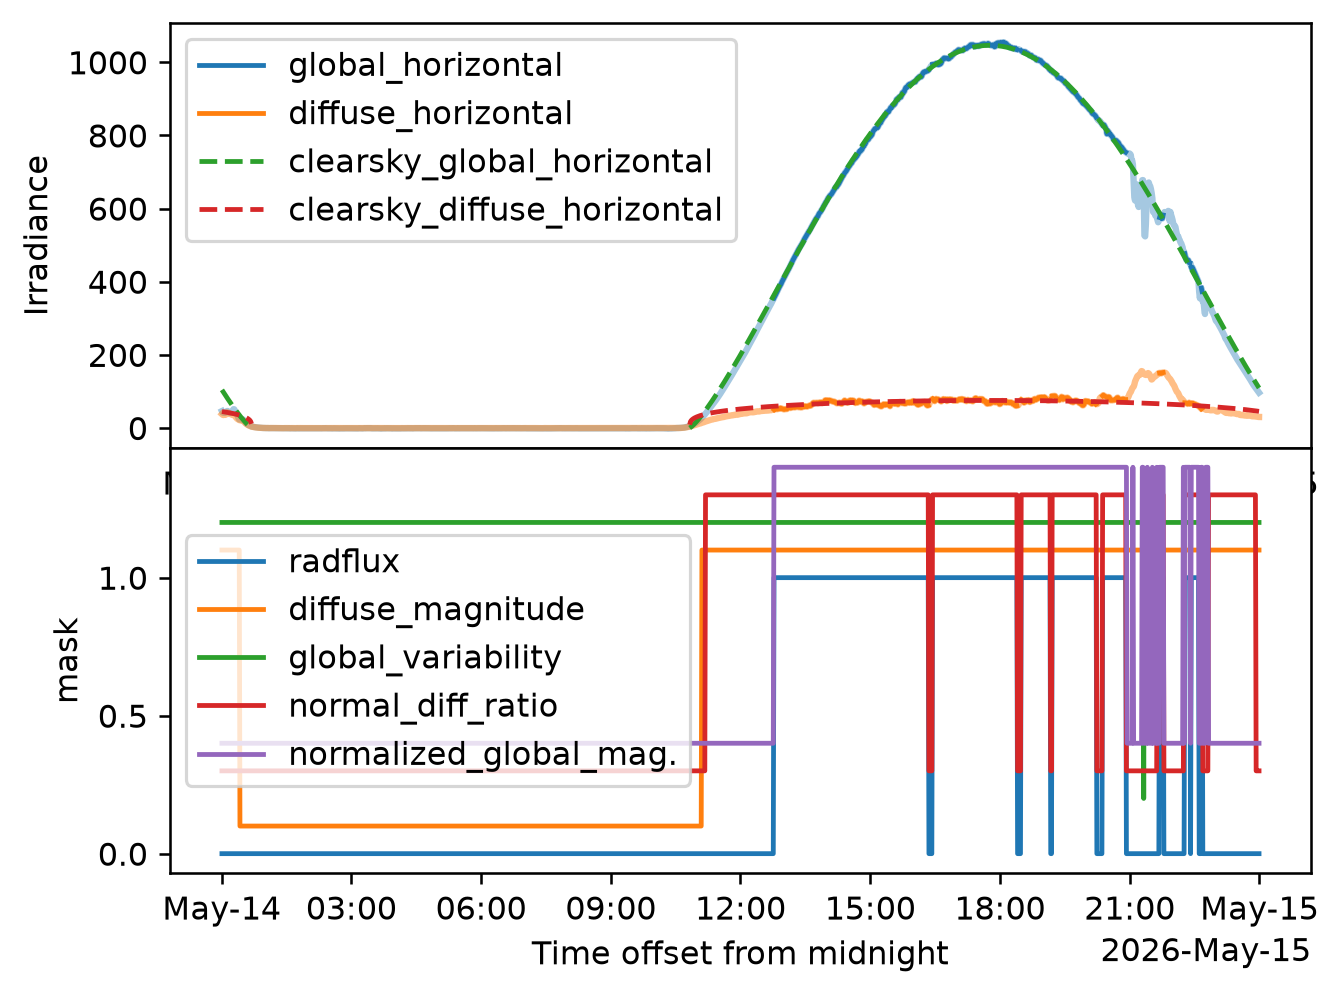

In [12]:

f,aa = plt.subplots(2, gridspec_kw={'hspace':0})
plot_data(ds, aa[0])
plot_mask(ds, aa[1])
# for a in aa:
#     a.set_xlim(pd.to_datetime('2026-05-14 21:00:00'), pd.to_datetime('2026-05-14 22:00:00'))

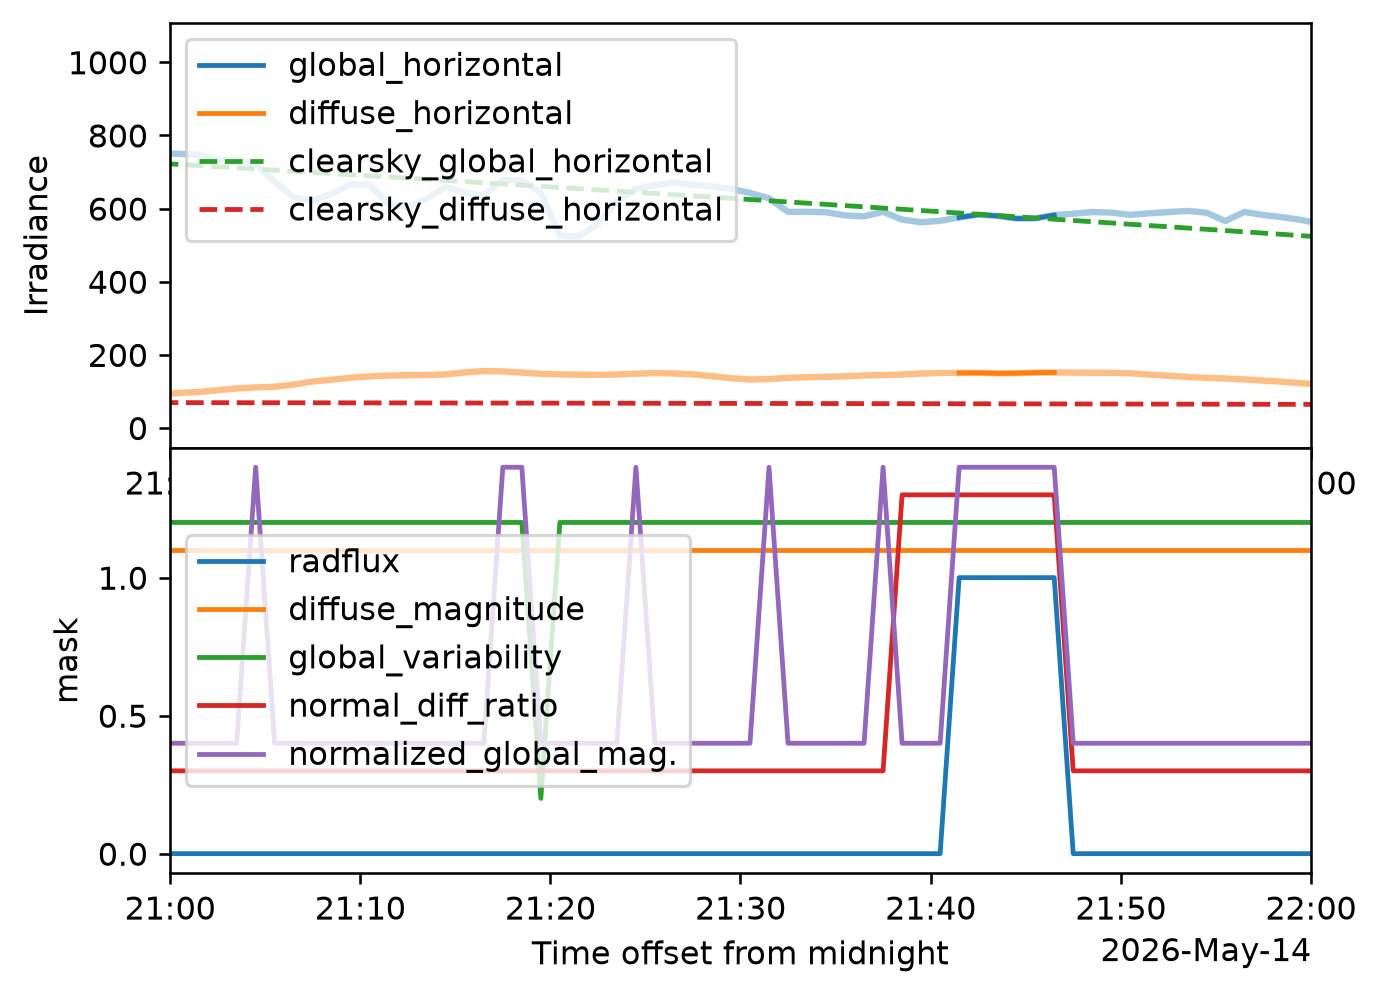

In [18]:

f,aa = plt.subplots(2, gridspec_kw={'hspace':0})
plot_data(ds, aa[0])
plot_mask(ds, aa[1])
for a in aa:
    a.set_xlim(pd.to_datetime('2026-05-14 21:00:00'), pd.to_datetime('2026-05-14 22:00:00'))

In [19]:
ds

<xarray.Dataset> Size: 336kB
Dimensions:                                    (time: 1440, bound: 2)
Coordinates:
  * time                                       (time) datetime64[ns] 12kB 202...
Dimensions without coordinates: bound
Data variables: (12/50)
    base_time                                  datetime64[ns] 8B ...
    time_offset                                (time) datetime64[ns] 12kB ...
    time_bounds                                (time, bound) datetime64[ns] 23kB ...
    down_short_hemisp                          (time) float32 6kB ...
    qc_down_short_hemisp                       (time) int32 6kB ...
    down_short_hemisp_clearsky                 (time) float64 12kB ...
    ...                                         ...
    rh_mean_std                                (time) float32 6kB ...
    clean_flag                                 (time) float32 6kB ...
    solar_zenith                               (time) float64 12kB ...
    solar_azimuth                              (time) float64 12kB ...
    solar_airmass                              (time) float64 12kB ...
    solar_sun_earth_distance                   (time) float64 12kB ...
Attributes: (12/35)
    Conventions:                   ARM-1.3
    process_version:               0.2
    dod_version:                   radsys43m60s-b1-1.0
    input_datastreams:             bnfradsys43m60sS10.b1
    site_id:                       bnf
    platform_id:                   radsys43m60s
    ...                            ...
    lat:                           34.3437276
    lon:                           -87.35044401
    alt:                           284
    input_files:                   bnfradsys43m60sS10.b1.20260514.000030.nc
    processing_date:               2026-08-27T13:50:25.937582
    processing_server:             telg-mbp.cmdl.noaa.gov